# 3.6 Implementing a Logistic Regression Classifier (Part 1)

## Loading the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("perceptron_toydata-truncated.txt", sep="\t")
df

,x1,x2,label
0,0.77,-1.14,0
1,-0.33,1.44,0
2,0.91,-3.07,0
3,-0.37,-1.91,0
4,-0.63,-1.53,0
5,0.39,-1.99,0
6,-0.49,-2.74,0
7,-0.68,-1.52,0
8,-0.10,-3.43,0
9,-0.05,-1.95,0


In [2]:
X_train = df[["x1", "x2"]].values
y_train = df["label"].values

In [3]:
X_train

array([[ 0.77, -1.14],
       [-0.33,  1.44],
       [ 0.91, -3.07],
       [-0.37, -1.91],
       [-0.63, -1.53],
       [ 0.39, -1.99],
       [-0.49, -2.74],
       [-0.68, -1.52],
       [-0.1 , -3.43],
       [-0.05, -1.95],
       [ 3.88,  0.65],
       [ 0.73,  2.97],
       [ 0.83,  3.94],
       [ 1.59,  1.25],
       [ 1.14,  3.91],
       [ 1.73,  2.8 ],
       [ 1.31,  1.85],
       [ 1.56,  3.85],
       [ 1.23,  2.54],
       [ 1.33,  2.03]])

In [4]:
X_train.shape

(20, 2)

In [5]:
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [6]:
y_train.shape

(20,)

In [7]:
import numpy as np

np.bincount(y_train)

array([10, 10])

## Visualizing the dataset

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", palette="colorblind", style="darkgrid")

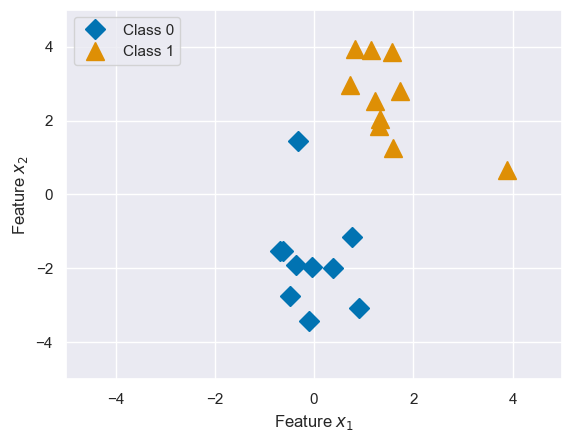

In [9]:
plt.plot(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="D",
    markersize=10,
    linestyle="",
    label="Class 0",
)

plt.plot(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="^",
    markersize=13,
    linestyle="",
    label="Class 1",
)

plt.legend(loc=2)

plt.xlim([-5, 5])
plt.ylim([-5, 5])

plt.xlabel("Feature $x_1$", fontsize=12)
plt.ylabel("Feature $x_2$", fontsize=12)

plt.show()

Standardize the data (will be explained later, but it centers the data around 0 and makes the std smaller)

In [10]:
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)

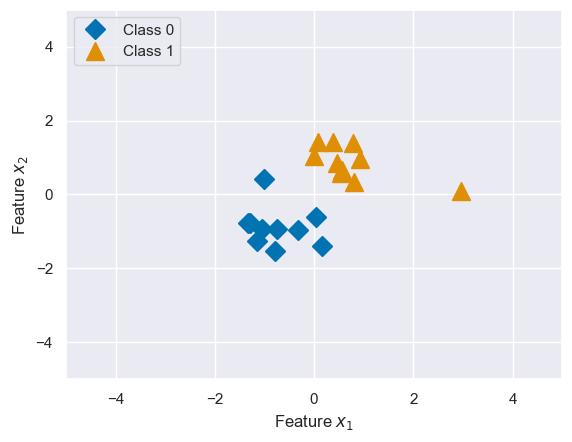

In [11]:
plt.plot(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="D",
    markersize=10,
    linestyle="",
    label="Class 0",
)

plt.plot(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="^",
    markersize=13,
    linestyle="",
    label="Class 1",
)

plt.legend(loc=2)

plt.xlim([-5, 5])
plt.ylim([-5, 5])

plt.xlabel("Feature $x_1$", fontsize=12)
plt.ylabel("Feature $x_2$", fontsize=12)

plt.show()

## Implementing the model

In [12]:
import torch


class LogisticRegression(torch.nn.Module):

    def __init__(self, num_features):
        super().__init__()
        # Linear layer, using num_features inputs and 1 output
        self.linear = torch.nn.Linear(num_features, 1)

    def forward(self, x):
        # compute logits i.e. weighted sum of inputs
        logits = self.linear(x)

        # apply sigmoid activation function
        # We don't need to do this, we can work directly with the logits as we saw above with binary_cross_entropy_with_logits
        probas = torch.sigmoid(logits)
        return probas

Let's try it on a single example

In [13]:
torch.manual_seed(1)

model = LogisticRegression(num_features=2)

In [14]:
x = torch.tensor([1.1, 2.1])

# Here we are disabling the computation graph because we're just using the model for prediction / inference
with torch.no_grad():
    proba = model(x)

# With newer versions of PyTorch, we can use torch.inference_mode() instead
with torch.inference_mode():
    proba = model(x)

print(proba)

tensor([0.4033])


## Defining a dataloader

In [15]:
from torch.utils.data import Dataset, DataLoader


# Custom dataset class that we can use to load our data
class MyDataset(Dataset):
    def __init__(self, X, y):
        # Convert the data to PyTorch tensors and set as features and labels
        self.features = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32)

    def __getitem__(self, index):
        # Return the feature and label at the given index
        x = self.features[index]
        y = self.labels[index]
        return x, y

    def __len__(self):
        # Return the number of samples in the dataset
        return self.labels.shape[0]


train_ds = MyDataset(X_train, y_train)

# We can now use the DataLoader class to create a data loader that will load the data in batches
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=10,
    shuffle=True,
)

In [16]:
X_train.shape

(20, 2)

## Training loop

In [17]:
import torch.nn.functional as F

# Initialize the model
torch.manual_seed(1)
model = LogisticRegression(num_features=2)

# Pass the parameters of the model to the optimizer so it knows which parameters to update
# We'll use stochastic gradient descent (SGD) with a learning rate of 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# Define the number of epochs
num_epochs = 20

for epoch in range(num_epochs):

    # Set the model to training mode (we'll explain more about this later)
    model = model.train()
    for batch_idx, (features, class_labels) in enumerate(train_loader):

        # Forward pass
        probas = model(features)

        # Compute the loss (we use .view() to reshape the labels to match the shape of the output)
        loss = F.binary_cross_entropy(probas, class_labels.view(probas.shape))

        # Zero gradients, backward pass, update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(
            f"Epoch: {epoch+1:02d}/{num_epochs:02d}"
            f" | Batch {batch_idx+1}/{len(train_loader)}"
            f" | Loss: {loss:.2f}"
        )

Epoch: 01/20 | Batch 1/2 | Loss: 0.67
Epoch: 01/20 | Batch 2/2 | Loss: 0.73
Epoch: 02/20 | Batch 1/2 | Loss: 0.67
Epoch: 02/20 | Batch 2/2 | Loss: 0.67
Epoch: 03/20 | Batch 1/2 | Loss: 0.60
Epoch: 03/20 | Batch 2/2 | Loss: 0.68
Epoch: 04/20 | Batch 1/2 | Loss: 0.69
Epoch: 04/20 | Batch 2/2 | Loss: 0.54
Epoch: 05/20 | Batch 1/2 | Loss: 0.61
Epoch: 05/20 | Batch 2/2 | Loss: 0.57
Epoch: 06/20 | Batch 1/2 | Loss: 0.59
Epoch: 06/20 | Batch 2/2 | Loss: 0.54
Epoch: 07/20 | Batch 1/2 | Loss: 0.51
Epoch: 07/20 | Batch 2/2 | Loss: 0.58
Epoch: 08/20 | Batch 1/2 | Loss: 0.51
Epoch: 08/20 | Batch 2/2 | Loss: 0.54
Epoch: 09/20 | Batch 1/2 | Loss: 0.51
Epoch: 09/20 | Batch 2/2 | Loss: 0.49
Epoch: 10/20 | Batch 1/2 | Loss: 0.53
Epoch: 10/20 | Batch 2/2 | Loss: 0.44
Epoch: 11/20 | Batch 1/2 | Loss: 0.42
Epoch: 11/20 | Batch 2/2 | Loss: 0.52
Epoch: 12/20 | Batch 1/2 | Loss: 0.46
Epoch: 12/20 | Batch 2/2 | Loss: 0.44
Epoch: 13/20 | Batch 1/2 | Loss: 0.46
Epoch: 13/20 | Batch 2/2 | Loss: 0.42
Epoch: 14/20

We see loss going down which is what we want

## Evaluating the results

The model returns probabilities

In [18]:
# last batch of the last epoch
probas

tensor([[0.6687],
        [0.6810],
        [0.2162],
        [0.7398],
        [0.2126],
        [0.5744],
        [0.3209],
        [0.6503],
        [0.4276],
        [0.2598]], grad_fn=<SigmoidBackward0>)

To convert these probabilities to labels, we can use `torch.where`

In [19]:
pred = torch.where(probas > 0.5, 1, 0)
pred

tensor([[1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [0]])

We can reshape the class labels to see how they compare

In [20]:
class_labels.view(pred.shape).to(pred.dtype)

tensor([[1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [0]])

In [21]:
def compute_accuracy(model, dataloader):

    # Set the model to evaluation mode
    model = model.eval()

    # Keep track of the number of correct predictions and the number of total examples
    correct = 0.0
    total_examples = 0

    for features, class_labels in dataloader:

        # Make predictions and do not update gradients
        with torch.inference_mode():
            probas = model(features)

        # Convert the output to binary predictions
        pred = torch.where(probas > 0.5, 1, 0)

        # Reshape the labels to match the shape of the predictions
        lab = class_labels.view(pred.shape).to(pred.dtype)

        # Compare the predictions to the labels
        compare = lab == pred

        # Update the number of correct predictions and the number of total examples
        correct += torch.sum(compare)
        total_examples += len(compare)

    # Compute the accuracy
    return correct / total_examples

In [22]:
train_acc = compute_accuracy(model, train_loader)
print(f"Accuracy: {train_acc*100}%")

Accuracy: 100.0%


## Optional: visualizing the decision boundary

In [23]:
def plot_boundary(model):
    """Plot the decision boundary. This is similar to what we did in unit 1, perceptron.py"""

    # Extract the weights and bias from the model
    w1 = model.linear.weight[0][0].detach()
    w2 = model.linear.weight[0][1].detach()
    b = model.linear.bias[0].detach()

    # Set some points far away from the origin to draw the line
    x1_min = -20
    x2_min = (-(w1 * x1_min) - b) / w2

    x1_max = 20
    x2_max = (-(w1 * x1_max) - b) / w2

    return x1_min, x1_max, x2_min, x2_max

Plot the data and the decision boundary

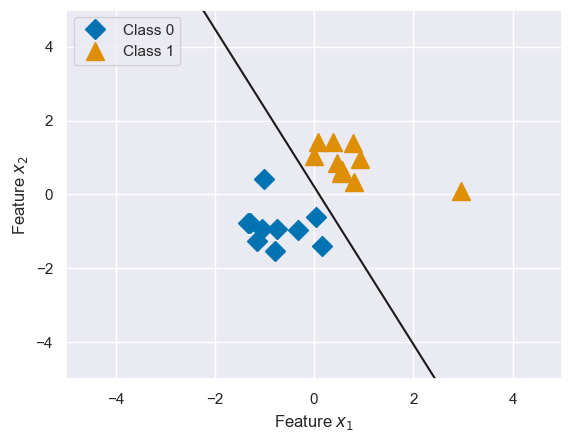

In [24]:
x1_min, x1_max, x2_min, x2_max = plot_boundary(model)

plt.plot(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="D",
    markersize=10,
    linestyle="",
    label="Class 0",
)

plt.plot(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="^",
    markersize=13,
    linestyle="",
    label="Class 1",
)

plt.plot([x1_min, x1_max], [x2_min, x2_max], color="k")

plt.legend(loc=2)

plt.xlim([-5, 5])
plt.ylim([-5, 5])

plt.xlabel("Feature $x_1$", fontsize=12)
plt.ylabel("Feature $x_2$", fontsize=12)

plt.show()